In [16]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from pathlib import Path
import pandas as pd 

from aux import plot_phase_space, plot_lattice, plot_solenoid_field_lattice
from data import parser
from structure import create_lebt
    
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Initial Bunch

In [17]:
B0 = parser()
M0 = B0.get_phase_space('%x %xp %y %yp %N')

x  = M0[:,0]
xp = M0[:,1]
y  = M0[:,2]
yp = M0[:,3]
No = M0[:,4]


#plot_phase_space(x, xp, "x [mm]", "x' [rad]")
#plot_phase_space(y, yp, "y [mm]", "y' [rad]")
#plot_phase_space(x, y,  "x [mm]", "y [mm]")
#plot_phase_space(xp, yp, "x' [mm]", "y' [rad]")



N: 15673, Mass: 11174.9 MeV, Energy: 0.182629 MeV, Frequency: 749.48 MHz, Current: 0.001 A, Charge: 6 e


### LEBT

K1_dip: 0.0 1/m^2, Bfield_dip: 0.08879570314655737 T
B:0.08879570314655737 T
N partículas iniciales: 15673
N partículas perdidas:  15673
Transmisión estimada:   0.0000 %
s de pérdida: min = 0.000172 m, max = 1.220000 m
x pérdidas:   media = -0.0620 mm, rms = 16.2381 mm
y pérdidas:   media = -0.0148 mm, rms = 16.0626 mm
xp pérdidas:  media = 48.9791 mrad, rms = 25646.8241 mrad
yp pérdidas:  media = -6.7161 mrad, rms = 23652.4499 mrad
p pérdidas:   media = 103.425598 MeV/c

Primeras pérdidas registradas:


,ID,s_loss [m],x [mm],xp [mrad],y [mm],yp [mrad],t [mm/c],p [MeV/c]
0,263,0.000480,-2.3195,-4002.7791,12.4048,13336.4879,167.1941,130.396406
1,264,0.000412,0.1030,-264.6457,6.4585,-3979.0853,138.7397,40.861431
2,265,0.000549,-9.6542,-7166.7558,-3.3173,-217.0773,151.8179,92.026052
3,266,0.000274,3.6600,1058.2674,-10.0627,-2377.4835,68.5923,68.174463
4,267,0.005557,-0.5766,-772.3679,2.0994,2157.6137,2595.0885,16.973336
5,268,0.064485,49.9072,765.5435,2.9875,43.4101,4200.8867,216.097184
6,269,0.001269,3.7143,-255.0456,-7.3279,-1070.6074,244.8291,24.325794
7,270,0.000206,3.4998,-2326.0513,-5.7496,1954.2183,82.9830,28.393257
8,271,0.011834,-37.1182,-49004.7107,-23.2350,-31060.6186,2780.6292,187.599113
9,272,0.000377,3.7478,-1128.5275,7.3594,-839.7219,104.0167,20.795402


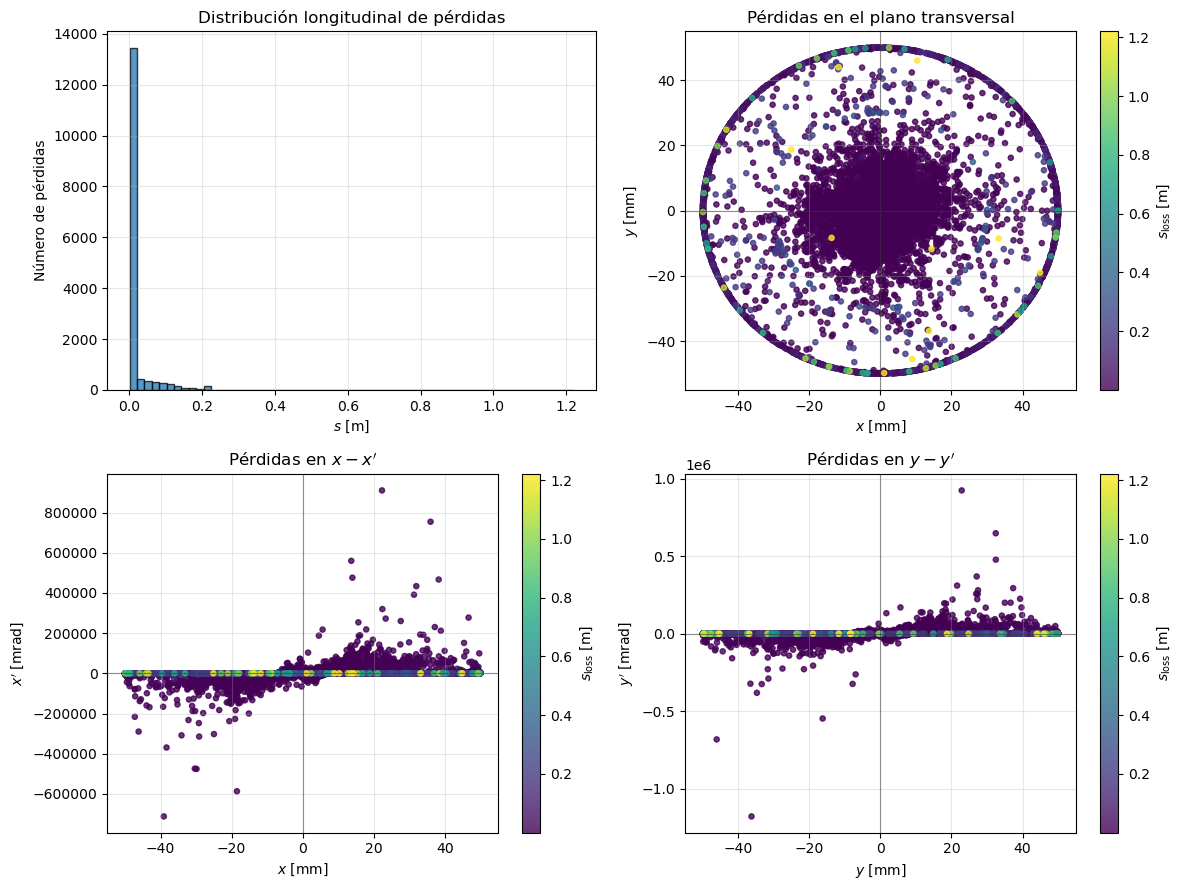

IndexError: index 0 is out of bounds for axis 1 with size 0

In [18]:
lebt = create_lebt(B0)

SC = rft.SpaceCharge_PIC_FreeSpace(16, 16, 16)
rft.cvar.SC_engine = SC

B1 = lebt.track(B0)
I = B1.get_info()

M = lebt.get_lost_particles()

# ============================================================
# Lost particles: plots + info
# ============================================================

M_lost = np.asarray(M, dtype=float)

if M_lost.size == 0:
    print("No hay partículas perdidas.")
else:
    M_lost = np.atleast_2d(M_lost)

    # --------------------------------------------------------
    # Columnas de get_lost_particles() para Lattice:
    # 0  X   [mm]
    # 1  XP  [mrad]
    # 2  Y   [mm]
    # 3  YP  [mrad]
    # 4  T   [mm/c]
    # 5  P   [MeV/c]
    # 6  S   [m]
    # 7  MASS [MeV/c^2]
    # 8  Q   [e]
    # 9  N   macro-particle charge
    # 10 ID
    # --------------------------------------------------------

    x_loss  = M_lost[:, 0]
    xp_loss = M_lost[:, 1]
    y_loss  = M_lost[:, 2]
    yp_loss = M_lost[:, 3]
    t_loss  = M_lost[:, 4]
    p_loss  = M_lost[:, 5]
    s_loss  = M_lost[:, 6]
    mass_loss = M_lost[:, 7]
    q_loss    = M_lost[:, 8]
    macro_q   = M_lost[:, 9]

    if M_lost.shape[1] > 10:
        id_loss = M_lost[:, 10].astype(int)
    else:
        id_loss = np.arange(len(M_lost))

    mask = (
        np.isfinite(x_loss)
        & np.isfinite(xp_loss)
        & np.isfinite(y_loss)
        & np.isfinite(yp_loss)
        & np.isfinite(t_loss)
        & np.isfinite(p_loss)
        & np.isfinite(s_loss)
    )

    x_loss  = x_loss[mask]
    xp_loss = xp_loss[mask]
    y_loss  = y_loss[mask]
    yp_loss = yp_loss[mask]
    t_loss  = t_loss[mask]
    p_loss  = p_loss[mask]
    s_loss  = s_loss[mask]
    mass_loss = mass_loss[mask]
    q_loss    = q_loss[mask]
    macro_q   = macro_q[mask]
    id_loss   = id_loss[mask]

    # ========================================================
    # Info global
    # ========================================================

    try:
        N0 = np.atleast_2d(B0.get_phase_space("%x")).shape[0]
    except:
        N0 = np.nan

    n_lost = len(s_loss)

    if np.isfinite(N0) and N0 > 0:
        transmission = 100.0 * (N0 - n_lost) / N0
        print(f"N partículas iniciales: {int(N0)}")
        print(f"N partículas perdidas:  {n_lost}")
        print(f"Transmisión estimada:   {transmission:.4f} %")
    else:
        print(f"N partículas perdidas: {n_lost}")

    print(f"s de pérdida: min = {np.min(s_loss):.6f} m, max = {np.max(s_loss):.6f} m")
    print(f"x pérdidas:   media = {np.mean(x_loss):.4f} mm, rms = {np.std(x_loss):.4f} mm")
    print(f"y pérdidas:   media = {np.mean(y_loss):.4f} mm, rms = {np.std(y_loss):.4f} mm")
    print(f"xp pérdidas:  media = {np.mean(xp_loss):.4f} mrad, rms = {np.std(xp_loss):.4f} mrad")
    print(f"yp pérdidas:  media = {np.mean(yp_loss):.4f} mrad, rms = {np.std(yp_loss):.4f} mrad")
    print(f"p pérdidas:   media = {np.mean(p_loss):.6f} MeV/c")

    # ========================================================
    # DataFrame resumen
    # ========================================================

    df_lost = pd.DataFrame({
        "ID": id_loss,
        "s_loss [m]": s_loss,
        "x [mm]": x_loss,
        "xp [mrad]": xp_loss,
        "y [mm]": y_loss,
        "yp [mrad]": yp_loss,
        "t [mm/c]": t_loss,
        "p [MeV/c]": p_loss,
    })

    print("\nPrimeras pérdidas registradas:")
    display(df_lost.head(15).style.format({
        "s_loss [m]": "{:.6f}",
        "x [mm]": "{:.4f}",
        "xp [mrad]": "{:.4f}",
        "y [mm]": "{:.4f}",
        "yp [mrad]": "{:.4f}",
        "t [mm/c]": "{:.4f}",
        "p [MeV/c]": "{:.6f}",
    }))

    # ========================================================
    # PLOTS
    # ========================================================

    fig, axs = plt.subplots(2, 2, figsize=(12, 9))

    # --------------------------------------------------------
    # 1) Histograma en s
    # --------------------------------------------------------
    axs[0, 0].hist(
        s_loss,
        bins=60,
        edgecolor="black",
        alpha=0.75
    )
    axs[0, 0].set_xlabel(r"$s$ [m]")
    axs[0, 0].set_ylabel("Número de pérdidas")
    axs[0, 0].set_title("Distribución longitudinal de pérdidas")
    axs[0, 0].grid(True, alpha=0.3)

    # --------------------------------------------------------
    # 2) Plano transversal x-y
    # --------------------------------------------------------
    sc_xy = axs[0, 1].scatter(
        x_loss,
        y_loss,
        c=s_loss,
        s=14,
        alpha=0.8
    )
    axs[0, 1].axhline(0, color="black", linewidth=0.8, alpha=0.4)
    axs[0, 1].axvline(0, color="black", linewidth=0.8, alpha=0.4)
    axs[0, 1].set_xlabel(r"$x$ [mm]")
    axs[0, 1].set_ylabel(r"$y$ [mm]")
    axs[0, 1].set_title("Pérdidas en el plano transversal")
    axs[0, 1].grid(True, alpha=0.3)
    cbar_xy = fig.colorbar(sc_xy, ax=axs[0, 1])
    cbar_xy.set_label(r"$s_\mathrm{loss}$ [m]")

    # --------------------------------------------------------
    # 3) Espacio de fases x-x'
    # --------------------------------------------------------
    sc_xxp = axs[1, 0].scatter(
        x_loss,
        xp_loss,
        c=s_loss,
        s=14,
        alpha=0.8
    )
    axs[1, 0].axhline(0, color="black", linewidth=0.8, alpha=0.4)
    axs[1, 0].axvline(0, color="black", linewidth=0.8, alpha=0.4)
    axs[1, 0].set_xlabel(r"$x$ [mm]")
    axs[1, 0].set_ylabel(r"$x'$ [mrad]")
    axs[1, 0].set_title(r"Pérdidas en $x-x'$")
    axs[1, 0].grid(True, alpha=0.3)
    cbar_xxp = fig.colorbar(sc_xxp, ax=axs[1, 0])
    cbar_xxp.set_label(r"$s_\mathrm{loss}$ [m]")

    # --------------------------------------------------------
    # 4) Espacio de fases y-y'
    # --------------------------------------------------------
    sc_yyp = axs[1, 1].scatter(
        y_loss,
        yp_loss,
        c=s_loss,
        s=14,
        alpha=0.8
    )
    axs[1, 1].axhline(0, color="black", linewidth=0.8, alpha=0.4)
    axs[1, 1].axvline(0, color="black", linewidth=0.8, alpha=0.4)
    axs[1, 1].set_xlabel(r"$y$ [mm]")
    axs[1, 1].set_ylabel(r"$y'$ [mrad]")
    axs[1, 1].set_title(r"Pérdidas en $y-y'$")
    axs[1, 1].grid(True, alpha=0.3)
    cbar_yyp = fig.colorbar(sc_yyp, ax=axs[1, 1])
    cbar_yyp.set_label(r"$s_\mathrm{loss}$ [m]")

    fig.tight_layout()
    plt.show()

M1 = B1.get_phase_space('%x %xp %y %yp %N')

x  = M1[:, 0]   # mm
xp = M1[:, 1]   # mrad
y  = M1[:, 2]   # mm
yp = M1[:, 3]   # mrad

def plot_rftrack_solenoid_field_pdf(
    element,
    s_sol_ini=2.9341,
    L=0.2574,
    z_pad=0.10,
    Nz=2000,
    plot_name="rftrack_solenoid_Bz.pdf",
    results_dir=Path("resultados"),
    ylim=None,
    show_legend=True,
    show_in_notebook=True,
):
    # ============================================================
    # Estilo pensado para subfiguras de 0.48\linewidth en LaTeX
    # ============================================================

    FIG_WIDTH = 6.2
    FIG_HEIGHT = 3.8

    FONT_SIZE = 18
    LABEL_SIZE = 20
    TICK_SIZE = 17
    LEGEND_SIZE = 15

    LINEWIDTH = 2.8
    AXVLINE_WIDTH = 2.0

    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    # ============================================================
    # Extraer campo de RF-Track
    # ============================================================

    z_rel = np.linspace(-z_pad, L + z_pad, Nz + 1)   # [m]
    s_abs = s_sol_ini + z_rel                        # [m]

    Bz = np.zeros_like(z_rel)

    x_mm = 0.0
    y_mm = 0.0
    t_mm_c = 0.0

    for i, s_i in enumerate(s_abs):
        z_mm = s_i * 1e3
        E, B = element.get_field(x_mm, y_mm, z_mm, t_mm_c)
        Bz[i] = np.asarray(B).ravel()[2]

    # ============================================================
    # Plot
    # ============================================================

    with plt.rc_context({
        "font.size": FONT_SIZE,
        "axes.labelsize": LABEL_SIZE,
        "xtick.labelsize": TICK_SIZE,
        "ytick.labelsize": TICK_SIZE,
        "legend.fontsize": LEGEND_SIZE,
        "mathtext.fontset": "dejavusans",
    }):

        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

        ax.plot(
            z_rel,
            Bz,
            linewidth=LINEWIDTH,
            label=r"$B_z$",
        )

        ax.axvline(
            0.0,
            color="k",
            linestyle="--",
            linewidth=AXVLINE_WIDTH,
            label="Entrada",
        )

        ax.axvline(
            L,
            color="k",
            linestyle=":",
            linewidth=AXVLINE_WIDTH,
            label="Salida",
        )

        ax.set_xlabel(r"$z$ [m]")
        ax.set_ylabel(r"$B_z$ [T]")

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.grid(True, alpha=0.3)

        ax.tick_params(
            axis="both",
            which="major",
            length=5,
            width=1.1,
        )

        if show_legend:
            ax.legend(
                frameon=True,
                loc="best",
                borderpad=0.35,
                handlelength=1.8,
                handletextpad=0.5,
            )

        fig.tight_layout(pad=0.4)

        plot_path = results_dir / plot_name
        fig.savefig(plot_path, bbox_inches="tight")

        if show_in_notebook:
            display(fig)

        plt.close(fig)

    print(f"Plot saved in: {plot_path}")
    print(f"Bz max = {np.max(Bz):.8e} T")
    print(f"Bz min = {np.min(Bz):.8e} T")

    return z_rel, Bz, s_abs

z_rel, Bz, s_abs = plot_rftrack_solenoid_field_pdf(
    element=lebt,
    s_sol_ini=2.9341,
    L=0.2574,
    z_pad=0.10,
    Nz=2000,
    plot_name="rftrack_lattice_solenoid_Bz.pdf",
    ylim=None,
    show_in_notebook=True,
)

# Save phassapce data to a text file
out_file = Path("rftrack_lat_sc_1mA_phase_space.txt")

data_phase = np.column_stack((x, xp, y, yp))

np.savetxt(
    out_file,
    data_phase,
    header="X[mm] xp[mrad] Y[mm] yp[mrad]",
    fmt="%.10e"
)
N=len(x)
print(N)

sigma_x_mm = np.std(x)
sigma_y_mm = np.std(y)

sigma_xp_mrad = np.std(xp) * 1e3
sigma_yp_mrad = np.std(yp) * 1e3

print("RF-Track final values")
print("---------------------")

print("\nX-X'")
print(f"emit_x      = {I.emitt_x:.6f} mm mrad")
print(f"Twiss beta_x = {I.beta_x:.6f} mm/mrad")
print(f"Twiss alpha_x = {I.alpha_x:.6f}")
print(f"sigma_x     = {sigma_x_mm:.6f} mm")
print(f"sigma_xp    = {sigma_xp_mrad/1000:.6f} mrad")

print("\nY-Y'")
print(f"emit_y      = {I.emitt_y:.6f} mm mrad")
print(f"Twiss beta_y = {I.beta_y:.6f} mm/mrad")
print(f"Twiss alpha_y = {I.alpha_y:.6f}")
print(f"sigma_y     = {sigma_y_mm:.6f} mm")
print(f"sigma_yp    = {sigma_yp_mrad/1000:.6f} mrad")

print("\n4D")
print(f"emit4D      = {I.emitt_4d**2:.6e} (mm mrad)^2")
print(f"tranmission  = {N/15673*100:.2f} %")



#plot_phase_space(x, xp, "x [mm]", "x' [rad]")
#plot_phase_space(y,yp,"y [mm]", "y' [rad]")
#plot_phase_space(x, y,  "x [mm]", "y [mm]")
#plot_phase_space(xp, yp, "x' [mm]", "y' [rad]")


T = lebt.get_transport_table('%S %sigma_x %sigma_y %N %mean_P %beta_x %beta_y %beta_z %alpha_x %alpha_y %alpha_z %mean_E %sigma_px %sigma_py')

s  = T[:, 0]
mx = T[:, 1]
my = T[:, 2]
N  = T[:, 3]
#N = np.full_like(mx,N)
P = T[:, 4]
beta_x = T[:, 5]
beta_y = T[:, 6]
beta_z = T[:, 7]
alpha_x = T[:, 8]
alpha_y = T[:, 9]
alpha_z = T[:, 10]
E_total = T[:, 11]          
sigma_px = T[:, 12]
sigma_py = T[:, 13]
mass_rf = 11174.9           
E = E_total - mass_rf     

# Save transport data to a text file
out_file = Path("rftrack_lat_sc_1mA_transport.txt")

data = np.column_stack((s, mx, my, N, P, beta_x, beta_y, beta_z, alpha_x, alpha_y, alpha_z, E, sigma_px, sigma_py))

np.savetxt(
    out_file,
    data,
    header="S[m] sigma_x[mm] sigma_y[mm] N mean_P[MeV/c] beta_x[mm/mrad] beta_y[mm/mrad] beta_z[mm/mrad] alpha_x[mrad] alpha_y[mrad] alpha_z[mrad] mean_E[MeV] sigma_px[mrad] sigma_py[mrad] ",
    fmt="%.10e"
)

results_dir = Path.cwd().resolve().parent / "beam_plots"
results_dir.mkdir(parents=True, exist_ok=True)

# Plot rms 
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
color_x = 'tab:blue'
color_y = 'tab:red'
ax.plot(s,  mx,  color=color_x, linewidth=2.5, linestyle='-',  label=r'$\sigma_x$')
ax.plot(s, -mx,  color=color_x, linewidth=1.8, linestyle='-')
ax.plot(s,  my,  color=color_y, linewidth=2.5, linestyle='-',  label=r'$\sigma_y$')
ax.plot(s, -my,  color=color_y, linewidth=1.8, linestyle='-')
plot_lattice(ax)
ax.set_xlabel('s [m]', fontsize=12)
ax.set_ylabel(r'$\sigma_{x,y}$ [mm]')


ax.set_ylim(-max(mx)*1.2, max(mx)*1.2)

ax.legend(loc='upper left') 
ax.grid(True, linestyle='--', alpha=0.4)

#plot_lattice(ax)

plt.tight_layout()
fig.savefig(results_dir / "rftrack_lebt_lattice.png", bbox_inches="tight")
plt.show()

#Plot transmission

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(s, N/15673*100, color='tab:red', linewidth=2.5, linestyle='-', label='Transmission')
plt.xlabel('s [m]', fontsize=12)
plt.ylabel('Transmission [%]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(results_dir / "rftrack_lebt_transmission.png", bbox_inches="tight")
plt.show()